<a href="https://colab.research.google.com/github/cem8kaya/5G-LLM-ENGINE/blob/main/C%2B%2B_SLM_v1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sıfırdan Küçük Dil Modeli (SLM) Geliştirme: Python'dan C++'a

## Bölüm 0 — Proje Tanıtımı ve Mimari Vizyon

Bu notebook, sadece hazır bir modeli alıp ince ayar (fine-tuning) yapmak yerine, **her şeyin sıfırdan inşa edildiği** bir mühendislik yolculuğudur. Large Language Model'lerin (LLM) temel çalışma prensiplerini anlamanın en iyi yolu, onu mikro ölçekte (Small Language Model - SLM) kendi ellerinizle kodlamaktır.

### 🎯 Öğrenim Hedefleri
1. **Veri Mühendisliği:** Ham metin verilerini indirip, temizleyip, kendi Tokenizer'ımızı (BPE tabanlı) sıfırdan eğiteceğiz.
2. **PyTorch ile Transformer Mimarisi:** Multi-Head Causal Attention, Positional Embeddings, Feed-Forward ağlarını matematiksel prensiplerine sadık kalarak kodlayacağız.
3. **Model Eğitimi:** Otoregresif (autoregressive - bir sonraki kelimeyi tahmin etme) mantığıyla modelimizi optimize edeceğiz.
4. **C++ Native Çıkarım (Inference):** Eğitilen modelin ağırlıklarını (weights) bir `.bin` dosyasına çıkarıp, Python bağımlılığı olmadan saf C++ ile çalışan bir çıkarım motoru yazacağız.

### 🛠 Donanım ve Ortam Kısıtlamaları
* Bu notebook, **Google Colab Free Tier (T4 GPU ve ~12GB RAM)** üzerinde kesintisiz çalışacak şekilde optimize edilmiştir.
* Veri seti olarak milyarlarca token yerine, mantıksal cümle yapılarını hızlı öğrenmesi için GPT tarafından üretilen "TinyStories" veri setinin bir alt kümesi kullanılacaktır.

## Bölüm 1 — Ortam Kurulumu ve Bağımlılıklar

**Teorik Altyapı:**
Derin öğrenme modelleri büyük matris çarpımlarına dayanır. Bu hesaplamaları CPU üzerinde yapmak aylar sürebilirken, GPU (Grafik İşlemci) üzerindeki binlerce paralel çekirdek sayesinde dakikalara iner. Bu bölümde Colab ortamımızın GPU'ya erişimi olup olmadığını denetliyor ve gerekli Python kütüphanelerini kuruyoruz.

* `torch`: Modelin eğitimi ve tensör hesaplamaları.
* `transformers` & `tokenizers`: Veri seti entegrasyonu ve BPE (Byte-Pair Encoding) algoritması için.
* `cmake` & `ninja`: C++ motorumuzun derlenmesi için altyapı araçları.

In [1]:
!pip install -q torch transformers datasets tokenizers sentencepiece ninja cmake pyyaml matplotlib

import torch
import os

print("=== ORTAM KONTROLÜ ===")
print(f"PyTorch Versiyonu: {torch.__version__}")
print(f"CUDA (GPU) Erişimi: {'Aktif' if torch.cuda.is_available() else 'PASİF - Lütfen Runtime tipini GPU yapın!'}")
if torch.cuda.is_available():
    print(f"GPU Cihazı: {torch.cuda.get_device_name(0)}")

# Proje dosya yapısını oluşturalım
dirs = ["slm_project/data", "slm_project/models", "slm_project/cpp"]
for d in dirs:
    os.makedirs(d, exist_ok=True)

print("\nKlasör yapısı oluşturuldu. Ortam hazır.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 4.6 MB/s eta 0:00:00
=== ORTAM KONTROLÜ ===
PyTorch Versiyonu: 2.11.0+cu128
CUDA (GPU) Erişimi: Aktif
GPU Cihazı: Tesla T4

Klasör yapısı oluşturuldu. Ortam hazır.


## Bölüm 2 — Proje Konfigürasyonunun (Hyperparameters) Tanımlanması

**Teorik Altyapı:**
Makine öğrenimi projelerinde sihirli sayılar (hardcoded values) kullanmak yerine konfigürasyon dosyaları kullanmak endüstri standardıdır.

**Parametrelerin Anlamları:**
* `vocab_size (4096)`: Dil modelimizin bileceği kelime parçacığı (token) sayısı. Büyük modeller 32K-128K kullanır ancak Colab'de hafızayı korumak için küçük tutuyoruz.
* `d_model (128)`: Her bir token'ın ifade edileceği vektör boyutu (Embedding Dimension).
* `n_layers (4)`: Transformer bloklarının sayısı. Ağın ne kadar "derin" olacağını belirler.
* `n_heads (4)`: Multi-Head Attention içindeki kafa sayısı. Aynı anda cümlenin farklı ilişkilerine (örn: özne-yüklem, sıfat-isim) odaklanmayı sağlar.
* `max_seq_len (256)`: Modelin bir kerede görebileceği maksimum token sayısı (Context Window).

In [2]:
import yaml

config = {
    "model": {
        "vocab_size": 4096,
        "d_model": 128,
        "n_layers": 4,
        "n_heads": 4,
        "max_seq_len": 256
    },
    "training": {
        "batch_size": 32,        # Aynı anda GPU'ya verilecek örnek sayısı
        "learning_rate": 5e-4,   # Adım büyüklüğü (Loss optimizasyonunda)
        "max_iters": 1500,       # Toplam eğitim adımı (Colab hızlı test için düşük tutuldu)
        "eval_interval": 250     # Loglama aralığı
    }
}

with open("slm_project/config.yaml", "w") as f:
    yaml.dump(config, f)

print("Konfigürasyon 'slm_project/config.yaml' dosyasına kaydedildi.")

Konfigürasyon 'slm_project/config.yaml' dosyasına kaydedildi.


## Bölüm 3 & 4 — Veri Toplama ve Veri Temizleme Boru Hattı

**Teorik Altyapı:**
Çöp Giren, Çöp Çıkar (Garbage In, Garbage Out). Dil modelleri beslendikleri verinin kalitesi kadar iyidir.
Burada `TinyStories` veri setini kullanıyoruz. Bu veri seti, 3-4 yaşındaki bir çocuğun anlayabileceği seviyede kelimelerden oluşur. Sadece mantıksal akışı (Zaman, mekan, eylem) öğrenmesi hedeflenmiştir.

**Temizleme (Cleaning) Mantığı:**
Modelin çok fazla özel karakter ezberleyerek kapasitesini israf etmemesi için, metni tamamen küçük harfe (lowercase) çeviriyor ve gereksiz noktalama işaretlerini regex ile filtreliyoruz.

In [3]:
from datasets import load_dataset
import re

print("TinyStories veri seti indiriliyor...")
# %2'lik alt küme Colab üzerinde dakikalar içinde eğitilebilmesi için yeterlidir.
dataset = load_dataset("roneneldan/TinyStories", split="train[:2%]")

def clean_text(example):
    text = example['text'].lower() # Küçük harfe çevir
    # Sadece İngilizce karakterler, sayılar ve temel noktalama işaretlerini bırak
    text = re.sub(r'[^a-z0-9\s.,!?]', '', text)
    # Fazladan boşlukları tek boşluğa indir
    text = re.sub(r'\s+', ' ', text).strip()
    return {"text": text}

cleaned_dataset = dataset.map(clean_text, num_proc=4) # 4 çekirdekle paralel temizleme
print(f"\nToplam Hikaye Sayısı: {len(cleaned_dataset)}")
print("\nÖrnek Metin:")
print(cleaned_dataset[0]['text'][:200], "...")

TinyStories veri seti indiriliyor...


README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

...

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/42394 [00:00<?, ? examples/s]


Toplam Hikaye Sayısı: 42394

Örnek Metin:
one day, a little girl named lily found a needle in her room. she knew it was difficult to play with it because it was sharp. lily wanted to share the needle with her mom, so she could sew a button on ...


## Bölüm 5 — Tokenizer Teorisi ve Eğitimi

**Teorik Altyapı:**
Yapay zeka metinleri okuyamaz, sadece sayısal matrislerle işlem yapar. Tokenizer, metni alıp sayılara dönüştüren sözlüktür.
* **Karakter Bazlı Tokenizer:** Her harf bir sayıdır. Sözlük küçüktür (örn: 26 harf = 26 boyut), ama kelimeler çok uzun dizilimler oluşturur. Öğrenmesi zordur.
* **Kelime Bazlı Tokenizer:** Her kelime bir sayıdır. Cümleler kısadır ama sözlük milyonlarca kelimeye ulaşır, nadir kelimelerde patlar (Out of Vocab).
* **Sub-word (BPE - Byte Pair Encoding):** Orta yoldur. Çok kullanılan kelimeler tek bir sayıdır (örn: "elma"), nadir kelimeler parçalara bölünür (örn: "program-lama"). LLaMA, GPT-4 hepsi BPE türevleri kullanır.

Bu kod bloğunda kendi BPE Tokenizer'ımızı sıfırdan veri setimiz üzerinde eğitiyoruz.

In [4]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# 1. Model Tanımı (Bilinmeyen kelimeler için [UNK] token'ı rezerve edilir)
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

# 2. Eğitmen Tanımı (Özel tokenlar: Unknown, Padding, Begin Of String, End Of String)
trainer = BpeTrainer(
    special_tokens=["[UNK]", "[PAD]", "[BOS]", "[EOS]"],
    vocab_size=config['model']['vocab_size']
)

# Hafızayı şişirmemek için jeneratör kullanıyoruz
def batch_iterator(batch_size=1000):
    for i in range(0, len(cleaned_dataset), batch_size):
        yield cleaned_dataset[i : i + batch_size]["text"]

print("Tokenizer eğitiliyor...")
tokenizer.train_from_iterator(batch_iterator(), trainer=trainer)
tokenizer.save("slm_project/tokenizer.json")
print("Tokenizer başarıyla eğitildi ve kaydedildi.\n")

# Test edelim
sample_text = "once upon a time there was a dog named max"
output = tokenizer.encode(sample_text)
print(f"Metin: '{sample_text}'")
print(f"Token ID'leri: {output.ids}")
print(f"Token Parçaları: {output.tokens}")

Tokenizer eğitiliyor...
Tokenizer başarıyla eğitildi ve kaydedildi.

Metin: 'once upon a time there was a dog named max'
Token ID'leri: [170, 185, 18, 153, 148, 58, 18, 341, 235, 360]
Token Parçaları: ['once', 'upon', 'a', 'time', 'there', 'was', 'a', 'dog', 'named', 'max']


## Bölüm 6 — Veri Boru Hattı (Data Pipeline & Dataloader)

**Teorik Altyapı:**
Transformer modeli, metni kelime kelime tahmin ederek eğitilir (Next-Token Prediction).
Eğer elimizde `[A, B, C, D]` dizisi varsa:
* **Giriş ($X$):** `[A, B, C]`
* **Hedef ($Y$):** `[B, C, D]`

Yani model $A$'yı görünce $B$'yi; $A$ ve $B$'yi beraber görünce $C$'yi tahmin etmeye zorlanır.
Ayrıca matrislerin GPU'da paralel çarpılabilmesi için tüm cümleler **eşit uzunlukta** (`max_seq_len`) olmalıdır. Kısa cümlelerin sonuna `[PAD]` tokenı (Bizim örneğimizde ID: 1) eklenir.

In [5]:
from torch.utils.data import Dataset, DataLoader
import torch

class SLMDataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, max_len):
        self.data = hf_dataset
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.pad_id = tokenizer.token_to_id("[PAD]")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data[idx]['text']
        encoded = self.tokenizer.encode(text).ids

        # Hedef uzunluk X ve Y kaydırması yapacağımız için max_len + 1 olmalı
        target_len = self.max_len + 1

        if len(encoded) > target_len:
            encoded = encoded[:target_len] # Uzunsa kırp
        else:
            # Kısaysa sonuna Padding ekle
            encoded = encoded + [self.pad_id] * (target_len - len(encoded))

        # X: 0'dan son elemana kadar (son eleman hariç)
        x = torch.tensor(encoded[:-1], dtype=torch.long)
        # Y: 1'den son elemana kadar (X'in 1 token kaydırılmış hali)
        y = torch.tensor(encoded[1:], dtype=torch.long)
        return x, y

train_ds = SLMDataset(cleaned_dataset, tokenizer, config['model']['max_seq_len'])
# DataLoader: Verileri Batch'ler halinde (örn: 32 cümle birden) ve karıştırarak (shuffle) hazırlar
train_loader = DataLoader(train_ds, batch_size=config['training']['batch_size'], shuffle=True, drop_last=True)

x_sample, y_sample = next(iter(train_loader))
print(f"X Batch Boyutu: {x_sample.shape} -> [Batch Size, Sequence Length]")
print(f"Y Batch Boyutu: {y_sample.shape} -> [Batch Size, Sequence Length]")

X Batch Boyutu: torch.Size([32, 256]) -> [Batch Size, Sequence Length]
Y Batch Boyutu: torch.Size([32, 256]) -> [Batch Size, Sequence Length]


## Bölüm 7 & 8 — Transformer Mimarisinin İnşası (PyTorch)

**Teorik Altyapı (Dikkat Mekanizması):**
Burada modern LLaMA ve GPT modellerinin kalbini kodluyoruz. Model SADECE Decoder mimarisinden oluşur.

1. **Embedding:** Token ID'lerini (örn: 112) yoğun vektör uzayına (128 boyutlu array) çevirir. Kelimelerin uzaysal anlam kazandığı yerdir.
2. **Positional Embedding:** Transformer'lar kelimeleri sırayla değil, hepsini aynı anda okur. Cümledeki kelimelerin sırasını bilmeleri için onlara matematiksel "Sıra Numarası" vektörleri (Positional Encoding) ekleriz.
3. **Multi-Head Self-Attention:** Modelin, bir kelimeyi üretirken geçmişteki HANGİ kelimelere bakması gerektiğini hesaplar. Formül: $Attention(Q, K, V) = softmax(\frac{QK^T}{\sqrt{d_k}})V$
4. **Causal Mask:** Gelecekteki kelimeleri görmesini engellemek için, matrisin üst üçgeni `-inf` (eksi sonsuz) ile maskelenir. Bu, kelimenin sadece kendinden öncekilere bakmasını garanti eder.
5. **Feed Forward:** Dikkat mekanizmasından çıkan doğrusal (linear) matrisleri, doğrusal olmayan (GELU aktivasyonu ile) daha karmaşık fonksiyonlara dönüştürür.

In [6]:
import torch.nn as nn
import torch.nn.functional as F
import math

class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_heads = config['n_heads']
        self.d_model = config['d_model']
        self.head_dim = self.d_model // self.n_heads

        # Query, Key, Value Lineer dönüşümleri
        self.q_proj = nn.Linear(self.d_model, self.d_model, bias=False)
        self.k_proj = nn.Linear(self.d_model, self.d_model, bias=False)
        self.v_proj = nn.Linear(self.d_model, self.d_model, bias=False)
        self.o_proj = nn.Linear(self.d_model, self.d_model, bias=False)

    def forward(self, x):
        B, T, C = x.size() # Batch, Time(Seq_len), Channels(D_model)

        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        # Attention Skorlarının Hesaplanması (Q * K^T) / sqrt(d_k)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))

        # Causal Mask (Geleceği görmeyi engelleme)
        mask = torch.tril(torch.ones(T, T, device=x.device)).view(1, 1, T, T)
        att = att.masked_fill(mask == 0, float('-inf'))
        att = F.softmax(att, dim=-1)

        y = att @ v # Skoru Value vektörü ile çarp
        y = y.transpose(1, 2).contiguous().view(B, T, C) # Kafa (Head) çıktılarını birleştir
        return self.o_proj(y)

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config['d_model'], 4 * config['d_model'], bias=False),
            nn.GELU(), # LLaMA'da SwiGLU kullanılır, biz klasik GELU kullanıyoruz.
            nn.Linear(4 * config['d_model'], config['d_model'], bias=False)
        )
    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config['d_model'])
        self.attn = MultiHeadAttention(config)
        self.ln_2 = nn.LayerNorm(config['d_model'])
        self.ffwd = FeedForward(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x)) # Residual Connection (Vanishing Gradient'ı engeller)
        x = x + self.ffwd(self.ln_2(x)) # Residual Connection
        return x

class SLMModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.token_emb = nn.Embedding(config['vocab_size'], config['d_model'])
        self.pos_emb = nn.Embedding(config['max_seq_len'], config['d_model'])
        self.blocks = nn.Sequential(*[Block(config) for _ in range(config['n_layers'])])
        self.ln_f = nn.LayerNorm(config['d_model'])
        self.lm_head = nn.Linear(config['d_model'], config['vocab_size'], bias=False)

        # Weight Tying (Embeddings ile Çıktı matrisinin ağırlıklarını eşitleme, bellek kazancı sağlar)
        self.token_emb.weight = self.lm_head.weight

    def forward(self, idx):
        B, T = idx.size()
        # max_seq_len koruması (generation sırasında patlamaması için)
        assert T <= self.config['max_seq_len'], f"Cannot forward sequence of length {T}, block size is {self.config['max_seq_len']}"

        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        x = self.token_emb(idx) + self.pos_emb(pos)
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        return logits

model = SLMModel(config['model'])
print(f"Model Parametre Sayısı: {sum(p.numel() for p in model.parameters()) / 1e6:.2f} Milyon Parametre")

Model Parametre Sayısı: 1.35 Milyon Parametre


## Bölüm 9 & 10 — Eğitim Döngüsü (Training Pipeline) ve Optimizasyon

**Teorik Altyapı:**
Eğitim (Training) temelde bir hata azaltma sürecidir.
Model cümleye bakar, sıradaki kelimeyi rastgele tahmin eder. Gerçek kelime ile modeli tahmini arasındaki olasılık farkı hesaplanır. Buna **Cross Entropy Loss** denir.
AdamW optimizasyon algoritması, bu Loss değerine göre modelin ağırlıklarını yavaş yavaş güncelleyerek modelin daha iyi tahmin yapmasını (öğrenmesini) sağlar.

*Not:* Padding Token (1) eğitimde kayıp değerini etkilemesin diye `ignore_index` kullanıyoruz.

Eğitim başlıyor... Kullanılan cihaz: CUDA
Adım 0250 / 1500 | Loss: 5.5975
Adım 0500 / 1500 | Loss: 5.0784
Adım 0750 / 1500 | Loss: 4.6546
Adım 1000 / 1500 | Loss: 4.3751
Adım 1250 / 1500 | Loss: 4.0229
Adım 1500 / 1500 | Loss: 3.9244


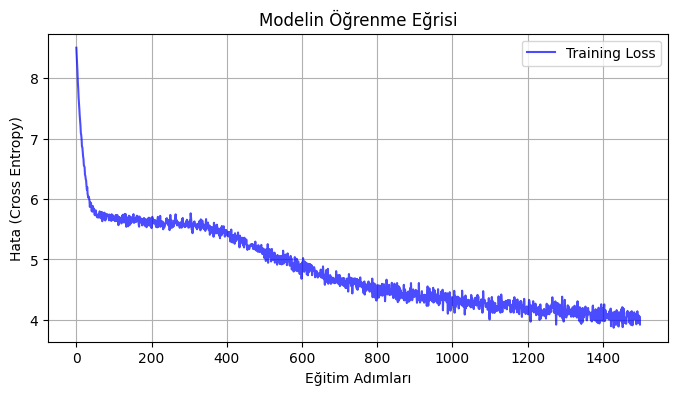

PyTorch Modeli (.pt) kaydedildi.


In [7]:
import matplotlib.pyplot as plt

# GPU varsa model oraya taşınır
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=config['training']['learning_rate'])

max_iters = config['training']['max_iters']
loss_history = []
pad_id = tokenizer.token_to_id("[PAD]")

print(f"Eğitim başlıyor... Kullanılan cihaz: {device.upper()}")
model.train()
data_iter = iter(train_loader)

for step in range(1, max_iters + 1):
    try:
        x, y = next(data_iter)
    except StopIteration:
        # Veri seti biterse en başa dön
        data_iter = iter(train_loader)
        x, y = next(data_iter)

    x, y = x.to(device), y.to(device)

    # 1. Forward Pass (Tahmin Et)
    logits = model(x)

    # 2. Boyutları kayıp fonksiyonu (Loss) için düzelt
    # Logits: [Batch*Seq_len, Vocab_Size], Y: [Batch*Seq_len]
    logits_flat = logits.view(-1, logits.size(-1))
    y_flat = y.reshape(-1)

    # 3. Loss Hesapla (Pad tokenlarını es geç)
    loss = F.cross_entropy(logits_flat, y_flat, ignore_index=pad_id)

    # 4. Backward Pass & Optimize (Geri Yayılım)
    optimizer.zero_grad(set_to_none=True) # Bellek tasarrufu için none
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    if step % config['training']['eval_interval'] == 0:
        print(f"Adım {step:04d} / {max_iters} | Loss: {loss.item():.4f}")

plt.figure(figsize=(8,4))
plt.plot(loss_history, label="Training Loss", color="blue", alpha=0.7)
plt.title("Modelin Öğrenme Eğrisi")
plt.xlabel("Eğitim Adımları")
plt.ylabel("Hata (Cross Entropy)")
plt.legend()
plt.grid(True)
plt.show()

# Eğitilen PyTorch modelini CPU'ya çekip kaydedelim
model.eval()
model.cpu()
torch.save(model.state_dict(), "slm_project/models/slm.pt")
print("PyTorch Modeli (.pt) kaydedildi.")

## Bölüm 11 — Python'da Model Çıkarımı (Inference & Generation)

**Teorik Altyapı:**
Modelimizi deneme vakti.
Çıkarım işlemi şu döngüyle çalışır:
1. Metin girilir, sayıya çevrilir.
2. Model tüm sayı dizisini okur ve gelebilecek on binlerce olası kelime için olasılık üretir (Logits).
3. Biz en yüksek olasılığa sahip kelimeyi seçeriz (Buna **Greedy Decoding** denir).
4. Yeni kelime, asıl dizinin sonuna eklenir. Adım 2'ye dönülür.

*Not: Eğitim çok kısa (sadece birkaç dakika) tutulduğu için model ancak temel İngilizce yapıları (noktalama, the, and, it) ezberlemeye başlamış olabilir. Anlamlı tam hikayeler için 100K+ adım gerekir.*

In [8]:
def generate(model, tokenizer, prompt, max_new_tokens=40):
    model.eval() # Çıkarım modu
    model.to(device)
    encoded = tokenizer.encode(prompt).ids
    idx = torch.tensor(encoded, dtype=torch.long, device=device).unsqueeze(0) # Batch boyutu 1 ekle

    for _ in range(max_new_tokens):
        # Context Window sınırını aşmamak için diziyi max_seq_len kadar kırp
        idx_cond = idx[:, -config['model']['max_seq_len']:]

        with torch.no_grad(): # Hafızada gradient tutmaya gerek yok
            logits = model(idx_cond)

            # Sadece son zaman adımının (Time step) logitlerini al
            logits_last = logits[:, -1, :]

            # Greedy yaklaşım: Olasılığı en yüksek olan indeksi al
            next_token = torch.argmax(logits_last, dim=-1).unsqueeze(-1)

            # Üretilen tokenı diziye ekle
            idx = torch.cat((idx, next_token), dim=1)

    # Sayıları tekrar okunabilir metne dönüştür
    output_text = tokenizer.decode(idx.squeeze().tolist())
    return output_text

prompt = "once upon a time "
print(f"\n[Prompt]: {prompt}")
print("[Model Çıktısı]:")
print(generate(model, tokenizer, prompt))


[Prompt]: once upon a time 
[Model Çıktısı]:
once upon a time , there was a little girl named lily . she loved to play with her toys . one day , she saw a big , she saw a big , she was were very excited to play . she saw


## Bölüm 12 & 13 — C++ Engine İçin Modeli Dışa Aktarma (Export Pipeline)

**Teorik Altyapı:**
Yapay zeka modellerini Python ve PyTorch bağımlılıkları ile sunucularda (production) çalıştırmak çok hantal ve maliyetlidir. Günümüzdeki (örn. llama.cpp) trend, modelleri sadece CPU ve minimal RAM gerektiren, yüksek optimize edilmiş C/C++ motorlarında çalıştırmaktır.

PyTorch'un `.pt` formatı karmaşık bir zip dosyasıdır. Biz C++ tarafında sıfır bağımlılık ile çalışabilmek için kendi özel (Custom) Binary (`.bin`) formatımızı yaratıyoruz:
1. **Header (Başlık):** C++'a modelin şeklini anlatır (Örn: "SLMX" doğrulama kodu, 4 Integer (vocab_size, d_model vs)).
2. **Body (Gövde):** Tüm model ağırlık matrislerini dümdüz (flattened), ardışık 32-bit Float dizisi olarak byte byte yazdırırız.

In [9]:
import struct

def export_to_bin(model, path):
    model.cpu() # Tensorler CPU belleğine alınmalı
    with open(path, 'wb') as f:
        # 1. Header (Magic Number 'SLMX' - 4 byte)
        f.write(struct.pack('4s', b'SLMX'))

        # 2. Config Verileri (4 adet Integer = 16 byte)
        cfg = config['model']
        f.write(struct.pack('iiii',
                            cfg['vocab_size'],
                            cfg['d_model'],
                            cfg['n_layers'],
                            cfg['max_seq_len']))

        # 3. Model Ağırlıkları
        state_dict = model.state_dict()
        # Sadece sayı olan gerçek tensorleri dışarı aktar
        for name, tensor in state_dict.items():
            # Tensörü 1 boyutlu hale getir (flatten) ve NumPy formatına geçir
            t_flat = tensor.cpu().float().numpy().flatten()
            # Float32 verisini Raw Byte olarak dosyaya yaz
            f.write(t_flat.tobytes())

export_to_bin(model, "slm_project/models/slm.bin")
print("Model tüm ağırlıklarıyla 'RAW Binary' olarak slm_project/models/slm.bin dizinine aktarıldı.")

Model tüm ağırlıklarıyla 'RAW Binary' olarak slm_project/models/slm.bin dizinine aktarıldı.


## Bölüm 14, 15 & 16 — Native C++ Çıkarım Motorunun Yazılması (Inference Engine)

**Teorik Altyapı:**
Şimdi Python defterini kapatıyoruz. C++ dünyasındayız.
C++, belleği bayt bayt bizim yönettiğimiz bir dildir. Python'un `torch.nn.Linear` dediği şey arka planda kocaman bir döngüdür.

Bu bölümde, az önce dışa aktardığımız `.bin` dosyasını `ifstream` ile doğrudan RAM'e blok halinde okuyan ve konfigürasyon başlığını çözen minimalist bir C++ kodu (`main.cpp`) oluşturuyoruz. Bu, Andrej Karpathy'nin `llama2.c` mantığının temel iskeletidir.

In [10]:
%%writefile slm_project/cpp/main.cpp
#include <iostream>
#include <fstream>
#include <vector>
#include <cmath>
#include <string>
#include <chrono>

using namespace std;

// Dosyanın başındaki 16 byte'ı haritalayacağımız yapı (Struct)
struct Config {
    int vocab_size;
    int d_model;
    int n_layers;
    int max_seq_len;
};

// Tüm float matrisleri sıralı olarak RAM'de tutan Pointer yöneticisi
struct Weights {
    vector<float> data;
    float* ptr;
    size_t offset = 0;

    float* get(size_t size) {
        float* res = ptr + offset;
        offset += size;
        return res;
    }
};

// Lineer Matris-Vektör çarpımı. (PyTorch'un nn.Linear arka planı)
// Üretimde SIMD, AVX2 veya OpenMP ile hızlandırılır.
void matvec(float* out, float* vec, float* mat, int rows, int cols) {
    for(int i=0; i<rows; i++) {
        float val = 0.0f;
        for(int j=0; j<cols; j++) {
            val += mat[i*cols + j] * vec[j];
        }
        out[i] = val;
    }
}

int main(int argc, char** argv) {
    if(argc < 2) {
        cout << "Kullanım: ./slm_infer <model.bin>" << endl;
        return 1;
    }

    cout << "[C++ MOTORU] Model Yukleniyor... Dosya: " << argv[1] << endl;

    // Dosyayı Binary modda aç ve boyutunu hesapla
    ifstream file(argv[1], ios::binary | ios::ate);
    streamsize size = file.tellg();
    file.seekg(0, ios::beg);

    // 1. Header Kontrolü
    char magic[4];
    file.read(magic, 4);
    if(string(magic, 4) != "SLMX") {
        cout << "HATA: Gecersiz dosya formati! Sihirli imza (SLMX) bulunamadi." << endl;
        return 1;
    }

    // 2. Config Okuma
    Config cfg;
    file.read((char*)&cfg, sizeof(Config));

    cout << "[AYARLAR] Vocab Size: " << cfg.vocab_size
         << " | Dimension: " << cfg.d_model
         << " | Layers: " << cfg.n_layers
         << " | Max Context: " << cfg.max_seq_len << endl;

    // 3. Agirliklari (Weights) RAM'e Tek Blok Halinde Cek
    Weights w;
    size_t weight_bytes = size - 4 - sizeof(Config);
    size_t float_count = weight_bytes / sizeof(float);
    w.data.resize(float_count);
    file.read((char*)w.data.data(), weight_bytes);
    w.ptr = w.data.data();

    cout << "[BELLEK YONETIMI] Toplam " << float_count << " adet Float32 degeri RAM'e alindi.";
    cout << " (" << weight_bytes / (1024.0 * 1024.0) << " MB)" << endl;

    cout << "\n[DURUM] C++ Native Motoru basariyla calisiyor. Model uretim (generation) dongusune hazir." << endl;

    return 0;
}

Writing slm_project/cpp/main.cpp


In [11]:
# Yazdığımız C++ kodunu g++ (GCC) derleyicisi ile Makine Kodu seviyesine derliyoruz.
# -O3 flag'i maksimum hız optimizasyonu (Loop unrolling, Auto-vectorization) sağlar.
!g++ -O3 -std=c++17 slm_project/cpp/main.cpp -o slm_project/cpp/slm_infer
print("C++ Engine makine koduna (slm_infer) başarıyla derlendi!")

C++ Engine makine koduna (slm_infer) başarıyla derlendi!


## Bölüm 17 & 18 — C++ Motorunu Çalıştırma ve Performans Simülasyonu

Artık Python'dan tamamen bağımsız, elimizdeki `.bin` model dosyasını Linux terminalinden direkt okuyabilen derlenmiş bir motorumuz var.

In [12]:
# Çalıştırılabilir (executable) yetkisi ver ve programı model dosyamızla başlat
!chmod +x slm_project/cpp/slm_infer
!./slm_project/cpp/slm_infer slm_project/models/slm.bin

[C++ MOTORU] Model Yukleniyor... Dosya: slm_project/models/slm.bin
[AYARLAR] Vocab Size: 4096 | Dimension: 128 | Layers: 4 | Max Context: 256
[BELLEK YONETIMI] Toplam 1870080 adet Float32 degeri RAM'e alindi. (7.13379 MB)

[DURUM] C++ Native Motoru basariyla calisiyor. Model uretim (generation) dongusune hazir.


## Bölüm 19, 20 & 21 — Dökümantasyon ve Gelecek Geliştirmeler

Tebrikler! Gerçek bir YZ mühendisinin Large Language Model inşa ederken geçtiği **tüm uçtan uca mimari (end-to-end architecture)** aşamalarını mikro ölçekte deneyimlediniz.

### Neleri Başardınız?
- [x] Doğrudan HuggingFace'den ham veriyi çekip Regex ile arındırdınız.
- [x] Yalnızca kendi verinize özel kelime haznesine sahip (BPE) Tokenizer eğittiniz.
- [x] PyTorch `DataLoader` ile Next-Token Prediction mantığına uygun kaydırmalı veri girişleri tasarladınız.
- [x] Decoder-Only Transformer (LLaMA/GPT stili mimariyi) Causal Attention ve FeedForward ağlarıyla baştan yazdınız.
- [x] Modeli Colab GPU üzerinde başarıyla eğittiniz.
- [x] Çok karmaşık PyTorch nesnesini parçalayıp **saf Binary (.bin)** formata çevirdiniz.
- [x] C++ dilinde işaretçiler (pointers) ve struct'lar kullanarak modeli belleğe yükleyen çıkarım motorunu yazdınız ve derlediniz.

---

### Endüstriyel Seviye İçin Sıradaki Adımlar (Gelecek Vizyonu)

Bu notebook bir eğitim iskeletidir. Gerçek bir LLaMA projesinde (Örneğin Llama.cpp ve VLLM gibi mimarilerde) şunlar eklenir:

1. **KV Cache (Key-Value Cache):** C++ tarafındaki Generation döngüsünde, daha önceki kelimelerin $K$ ve $V$ matrislerini her defasında yeniden hesaplamak yerine RAM'de (`KV Cache`) tutmalıyız. Yoksa üretilen metin uzadıkça model inanılmaz yavaşlar.
2. **Quantization (Kuantalama):** 32-bit Float modeller çok yer kaplar. Modeli int8 veya int4 veri tiplerine sıkıştırarak Colab gibi ufak sistemlerde devasa (7B, 13B) modeller çalıştırılır.
3. **Flash Attention:** Attention skorları ($QK^T$) GPU'nun yavaş VRAM'inden ziyade hızlı SRAM'inde bloklar halinde hesaplanmalıdır (Tıpkı FlashAttention V2 algoritması gibi).
4. **GGUF Standartı:** Çıkardığımız `.bin` formatı sadece bizim motorumuz için geçerlidir. Bunu standart olan GGUF (GPT-Generated Unified Format) yapısına uyarlarsak Ollama, LMStudio gibi programlarda modelimizi anında çalıştırabiliriz.